In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load data
data_path = "autodl-tmp/Anonymizing_suicide_datasets.csv"
df = pd.read_csv(data_path)

# Ensure time column is datetime format, and sort by user and time
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(by=['users', 'time']).reset_index(drop=True)

# Basic processing of text features
df['text'] = df['text'].fillna('').astype(str)
df['text_length'] = df['text'].apply(len)
df['hour'] = df['time'].dt.hour
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 22 or x <= 4) else 0)

print(f"Total number of original posts: {len(df)}")

Total number of original posts: 14613


In [3]:
user_features = []

# Iterate through each user and construct features using a sliding window
for user, group in df.groupby('users'):
    group = group.reset_index(drop=True)
    # Pre-calculate the time intervals for all posts of the user
    group['time_diff'] = group['time'].diff().dt.total_seconds() / 3600
    group['time_diff'] = group['time_diff'].fillna(0)
    
    for i in range(len(group)):
        # Extract the current post and trace back up to 4 historical posts (forming a stable 5-element window)
        window_start = max(0, i - 4)
        window_df = group.iloc[window_start:i+1]
        
        # The target label is the sentiment of the latest current post
        label = window_df['sentiment'].iloc[-1]
        
        # Concatenate text within the window
        combined_text = " ".join(window_df['text'].tolist())
        
        # Aggregate behavioral features
        avg_time_diff = window_df['time_diff'].mean()
        night_post_ratio = window_df['is_night'].mean() 
        avg_text_length = window_df['text_length'].mean()
        length_std = window_df['text_length'].std() if len(window_df) > 1 else 0 
        post_count = len(window_df) 
        
        user_features.append({
            'users': user,
            'combined_text': combined_text,
            'avg_time_diff': avg_time_diff,
            'night_post_ratio': night_post_ratio,
            'avg_text_length': avg_text_length,
            'length_std': length_std,
            'post_count': post_count,
            'label': label
        })

df_users = pd.DataFrame(user_features)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=150, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_users['combined_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_{i}' for i in range(150)])

# Concatenate all features
df_final = pd.concat([df_users.drop(columns=['combined_text']), tfidf_df], axis=1)

# Label encoding
le = LabelEncoder()
df_final['label_encoded'] = le.fit_transform(df_final['label'])

# Prepare training data X, y and groups
drop_cols = ['users', 'label', 'label_encoded']
X = df_final.drop(columns=drop_cols)
y = df_final['label_encoded']
groups = df_final['users'] # Must keep the user column for grouped cross-validation

print(f"Sliding window feature construction completed, total number of samples: {len(df_final)}")

Sliding window feature construction completed, total number of samples: 14613


In [4]:
# Use GroupKFold to strictly prevent sliding window data from the same user from appearing in both training and validation sets
gkf = GroupKFold(n_splits=5)
rf = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)

# Store all true labels and predicted labels for final metric calculation
all_y_true = []
all_y_pred = []
feature_importances = np.zeros(X.shape[1])

print("Starting 5-Fold grouped cross-validation...")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train the model
    rf.fit(X_train, y_train)
    
    # Predict and evaluate
    preds = rf.predict(X_val)
    
    # Collect prediction results
    all_y_true.extend(y_val)
    all_y_pred.extend(preds)
    
    # Accumulate feature importances
    feature_importances += rf.feature_importances_
    print(f"Fold {fold} training completed.")

Starting 5-Fold grouped cross-validation...
Fold 1 training completed.
Fold 2 training completed.
Fold 3 training completed.
Fold 4 training completed.
Fold 5 training completed.


In [5]:
# Calculate overall Acc and Mac-F1
acc = accuracy_score(all_y_true, all_y_pred)
mac_f1 = f1_score(all_y_true, all_y_pred, average='macro')

# Get F1 scores for each class
class_f1s = f1_score(all_y_true, all_y_pred, average=None)
class_names = le.classes_
f1_dict = {class_names[i]: class_f1s[i] for i in range(len(class_names))}

print("\n" + "="*30)
print("Random Forest 5-Fold Cross-Validation Results:")
print(f"Acc. (%): {acc * 100:.1f}")
print(f"Mac-F1 (%): {mac_f1 * 100:.1f}")
print(f"IN-F1 (%): {f1_dict.get('Indicator', 0) * 100:.1f}")
print(f"ID-F1 (%): {f1_dict.get('Ideation', 0) * 100:.1f}")
print(f"BR-F1 (%): {f1_dict.get('Behavior', 0) * 100:.1f}")
print(f"AT-F1 (%): {f1_dict.get('Attempt', 0) * 100:.1f}")
print("="*30)


Random Forest 5-Fold Cross-Validation Results:
Acc. (%): 53.5
Mac-F1 (%): 30.4
IN-F1 (%): 48.1
ID-F1 (%): 64.9
BR-F1 (%): 6.8
AT-F1 (%): 1.9


=== Feature Importance ===
  TF-IDF_Words (Sum): 0.9218
     avg_text_length: 0.0330
       avg_time_diff: 0.0192
          length_std: 0.0185
          post_count: 0.0075
    night_post_ratio: 0.0000


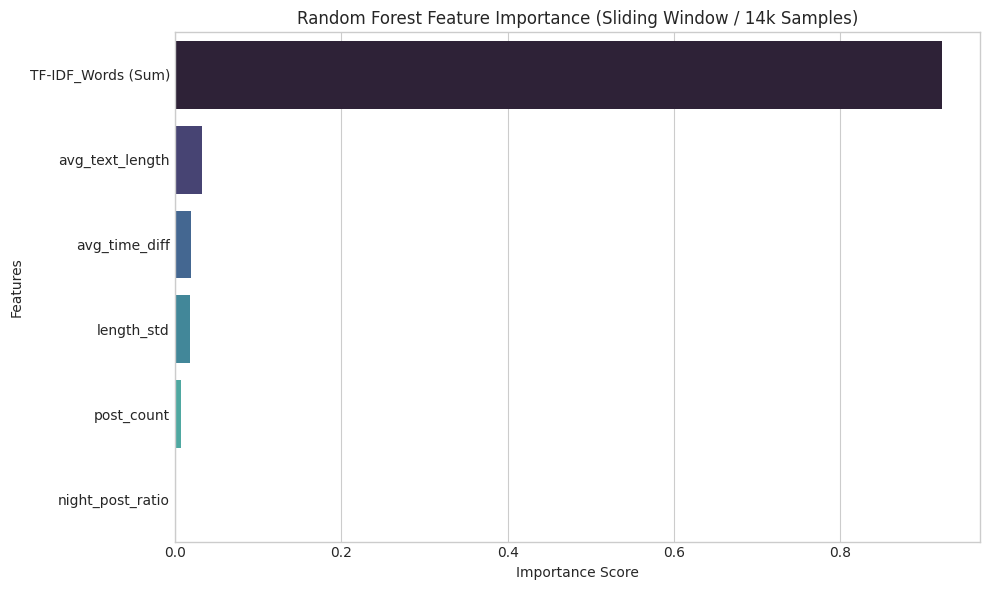

In [6]:
# Calculate average feature importance across 5 folds
avg_feature_importances = feature_importances / 5

# Create feature importance DataFrame 
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': avg_feature_importances
})

# Sum up the feature importance of all TF-IDF words and display as a whole
tfidf_importance = fi_df[fi_df['Feature'].str.startswith('tfidf_')]['Importance'].sum()
fi_df_clean = fi_df[~fi_df['Feature'].str.startswith('tfidf_')].copy()

# Add the summarized TF-IDF
fi_df_clean.loc[len(fi_df_clean)] = ['TF-IDF_Words (Sum)', tfidf_importance]

# Sort in descending order and select top 15 important features
fi_df_clean = fi_df_clean.sort_values(by='Importance', ascending=False).head(15)

# Print specific sorted values
print("=== Feature Importance ===")
for i, row in fi_df_clean.head(10).iterrows():
    print(f"{row['Feature']:>20}: {row['Importance']:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df_clean, palette='mako')
plt.title('Random Forest Feature Importance (Sliding Window / 14k Samples)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()